In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, usecols=[1])   # second column has passenger counts
data = df.values.astype('float32')   # shape (144, 1)
print(data.shape)

(144, 1)


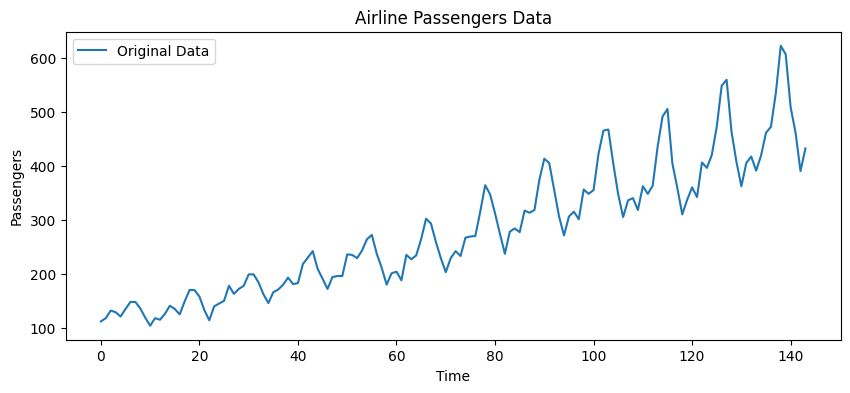

In [4]:
plt.figure(figsize=(10,4))
plt.plot(data, label='Original Data')
plt.title("Airline Passengers Data")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [5]:
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)   # values in [0,1]

In [6]:
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])   # sequence of length look_back
        Y.append(dataset[i + look_back, 0])       # next value
    return np.array(X), np.array(Y)

look_back = 3
X, y = create_dataset(data_scaled, look_back)
print(X.shape, y.shape)   # X -> (samples, look_back), y -> (samples,)

(141, 3) (141,)


In [7]:
train_size = int(len(X) * 0.67)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(X_train.shape, X_test.shape)

(94, 3) (47, 3)


In [8]:
X_train = X_train.reshape((X_train.shape[0], look_back, 1))
X_test  = X_test.reshape((X_test.shape[0],  look_back, 1))
print(X_train.shape, X_test.shape)

(94, 3, 1) (47, 3, 1)


In [11]:
model = Sequential([
    Input(shape=(look_back, 1)),
    LSTM(50, return_sequences=False),   # 50 LSTM units
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=1,
    validation_data=(X_test, y_test),
    verbose=2
)

Epoch 1/50
94/94 - 3s - 29ms/step - loss: 0.0118 - val_loss: 0.0357
Epoch 2/50
94/94 - 0s - 5ms/step - loss: 0.0051 - val_loss: 0.0248
Epoch 3/50
94/94 - 0s - 5ms/step - loss: 0.0046 - val_loss: 0.0226
Epoch 4/50
94/94 - 0s - 4ms/step - loss: 0.0045 - val_loss: 0.0218
Epoch 5/50
94/94 - 0s - 5ms/step - loss: 0.0044 - val_loss: 0.0214
Epoch 6/50
94/94 - 0s - 5ms/step - loss: 0.0043 - val_loss: 0.0210
Epoch 7/50
94/94 - 1s - 9ms/step - loss: 0.0042 - val_loss: 0.0206
Epoch 8/50
94/94 - 1s - 6ms/step - loss: 0.0041 - val_loss: 0.0202
Epoch 9/50
94/94 - 1s - 8ms/step - loss: 0.0040 - val_loss: 0.0199
Epoch 10/50
94/94 - 1s - 5ms/step - loss: 0.0040 - val_loss: 0.0195
Epoch 11/50
94/94 - 0s - 5ms/step - loss: 0.0039 - val_loss: 0.0192
Epoch 12/50
94/94 - 0s - 5ms/step - loss: 0.0038 - val_loss: 0.0189
Epoch 13/50
94/94 - 0s - 4ms/step - loss: 0.0038 - val_loss: 0.0186
Epoch 14/50
94/94 - 0s - 4ms/step - loss: 0.0037 - val_loss: 0.0183
Epoch 15/50
94/94 - 0s - 4ms/step - loss: 0.0036 - val_l

In [13]:
train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

train_pred_inv = scaler.inverse_transform(train_pred.reshape(-1,1))
y_train_inv     = scaler.inverse_transform(y_train.reshape(-1,1))

test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1,1))
y_test_inv     = scaler.inverse_transform(y_test.reshape(-1,1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [14]:
test_mae = mean_absolute_error(y_test_inv, test_pred_inv)
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))
print(f"Test MAE: {test_mae:.2f}, Test RMSE: {test_rmse:.2f}")

Test MAE: 38.17, Test RMSE: 46.02


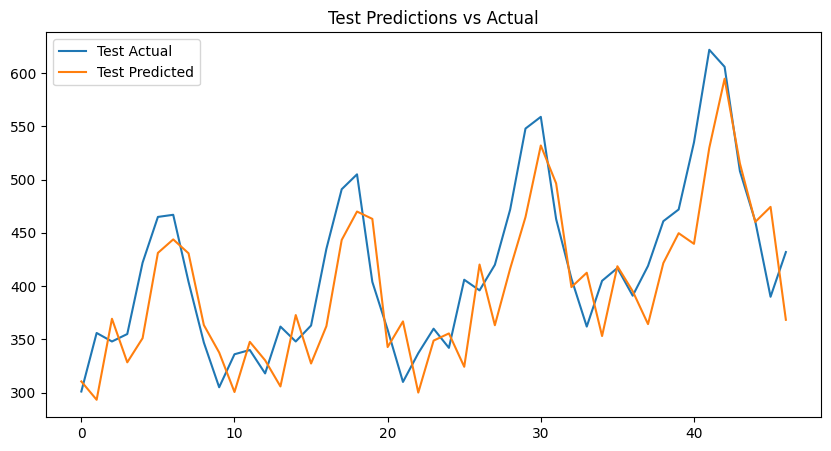

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Test Actual')
plt.plot(test_pred_inv, label='Test Predicted')
plt.title("Test Predictions vs Actual")
plt.legend()
plt.show()